IMPORTAR LIBRERIAS:

In [177]:
from google.colab import drive
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelo
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

Montamos el drive donde se encuentran los datasets y definimos la ruta base hacia ellos:

In [178]:
# Montar Google Drive (para acceder al archivo JSON)
drive.mount('/content/drive',force_remount=True)

# Definir rutas de archivos y conexión
ruta_base = "/content/drive/My Drive/Colab Notebooks/Curso ETL/Laboratorio_2/Data/"

Mounted at /content/drive


EXTRACCIÓN DE DATOS:

In [179]:
# Definir la ruta con nombre del archivo CSV en Google Drive
ruta_csv = ruta_base + "lab2_trial_conversion_users.csv"
# Leer archivo CSV delimitado por ','
#df_csv = pd.read_csv(ruta_csv, delimiter=",")
df = pd.read_csv(ruta_csv)

# Vista inicial
#df.head()
df.info()
#df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2545 entries, 0 to 2544
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           2545 non-null   object 
 1   signup_date                       2545 non-null   object 
 2   trial_end_date                    2545 non-null   object 
 3   trial_length_days                 2545 non-null   int64  
 4   age                               2469 non-null   float64
 5   country                           2506 non-null   object 
 6   gender                            2545 non-null   object 
 7   device_type                       2504 non-null   object 
 8   acquisition_channel               2545 non-null   object 
 9   city_tier                         2545 non-null   object 
 10  preferred_plan_before_conversion  2545 non-null   object 
 11  days_active_trial                 2545 non-null   int64  
 12  sessio

EXPLORACION DE DATOS:

In [180]:
# Nulos
print (df.isnull().sum())

user_id                               0
signup_date                           0
trial_end_date                        0
trial_length_days                     0
age                                  76
country                              39
gender                                0
device_type                          41
acquisition_channel                   0
city_tier                             0
preferred_plan_before_conversion      0
days_active_trial                     0
sessions_count                        0
avg_session_minutes                 102
features_used                         0
support_tickets                       0
emails_opened                         0
webinar_attended                      0
payment_method_on_file                0
referred_friend                       0
discount_offered_pct                  0
plan_page_views                       0
last_activity_gap_days                0
satisfaction_score                  152
monthly_income_usd                  119


In [181]:
# Visualizar duplicados
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
2540     True
2541     True
2542    False
2543     True
2544     True
Length: 2545, dtype: bool


TRANSFORMACION DE DATOS:

In [182]:
# Eliminar espacios raros
df['user_id'] = df['user_id'].astype(str).str.strip()

# Ver duplicados (NO eliminar todos automáticamente)
duplicates = df[df.duplicated(subset='user_id', keep=False)]
print("Duplicados:", duplicates.shape[0])
# conservar el más reciente
df = df.sort_values('signup_date').drop_duplicates('user_id', keep='last')

Duplicados: 90


In [183]:
# Corregimos los nombres de paises en mayuscula inicial
df['country'] = df['country'].str.strip().str.title()

In [184]:
# Verificacion de fechas
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['trial_end_date'] = pd.to_datetime(df['trial_end_date'], errors='coerce')
# Validación
df[['signup_date','trial_end_date']].isnull().sum()

,0
signup_date,2421
trial_end_date,151


In [185]:
# Verificacion de variable porcentaje
df['discount_offered_pct'] = (
    df['discount_offered_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip())
df['discount_offered_pct'] = pd.to_numeric(df['discount_offered_pct'], errors='coerce')
print(df.discount_offered_pct.head())

1323    15
1762    15
1358     5
1915    15
2105     0
Name: discount_offered_pct, dtype: int64


In [186]:
# Verificacion de variable dinero
df['monthly_income_usd'] = (
    df['monthly_income_usd']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False))
df['monthly_income_usd'] = pd.to_numeric(df['monthly_income_usd'], errors='coerce')
print(df.monthly_income_usd.head())

1323    2310.0
1762    1488.0
1358    1145.0
1915    2618.0
2105    1469.0
Name: monthly_income_usd, dtype: float64


In [187]:
# Verificiacion de variables categorias en string
cat_cols = [
    'country', 'gender', 'device_type', 'acquisition_channel',
    'city_tier', 'preferred_plan_before_conversion', 'selected_plan']
for col in cat_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

In [188]:
# Verificacion de variables binarias
binary_cols = [
    'webinar_attended',
    'payment_method_on_file',
    'referred_friend',
    'converted_to_paid_plan']
for col in binary_cols:
    df[col] = df[col].astype(int)

In [189]:
# Verificacion de variables numericas
num_cols = [
    'trial_length_days','age','days_active_trial','sessions_count',
    'avg_session_minutes','features_used','support_tickets',
    'emails_opened','plan_page_views','last_activity_gap_days',
    'satisfaction_score']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [190]:
# Manejo de nulos numéricos : mediana
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Manejo de nulos categóricos : moda
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [191]:
# Verificacion de valores coherentes
df = df[df['age'] > 0]
df = df[df['avg_session_minutes'] >= 0]
df = df[df['monthly_income_usd'] >= 0]

In [192]:
# Outliers Método IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    imite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], imite_inferior, limite_superior)

FEATURE ENGINEERING:

In [193]:
# Intensidad de uso
df['usage_intensity'] = df['sessions_count'] / (df['days_active_trial'] + 1)

# Puntuación de uso
df['engagement_score'] = (
    df['sessions_count'] +
    df['emails_opened'] +
    df['features_used'])

# Alta intención de compra
df['high_intent'] = (
    (df['payment_method_on_file'] == 1) &
    (df['plan_page_views'] > 3)
).astype(int)

In [194]:
df_copy = df.copy()

PREPARACIÓN PARA MODELADO:

In [195]:
# Variables
target = 'converted_to_paid_plan'

#X = df.drop(columns=[target, 'user_id'])  # eliminar ID
X = df[[
    # Variables originales
    'days_active_trial',
    'sessions_count',
    'avg_session_minutes',
    'features_used',
    'plan_page_views',
    'last_activity_gap_days',
    'payment_method_on_file',
    'discount_offered_pct',
    'emails_opened',
    'webinar_attended',

    # Features derivadas
    'usage_intensity',
    'engagement_score',
    'high_intent'
]]
y = df[target]

In [196]:
# Retiramos variable sesgo
leakage_cols = ['selected_plan']
X = df.drop(columns=[target, 'user_id'] + leakage_cols)

In [197]:
#Separación entrenamiento=60%, evaluacion=20% y  validacion=20%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.7, stratify=y, random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=42
)

PIPELINE DE PREPROCESAMIENTO:

In [198]:
# Identificacion de tipo de variable
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)])

In [199]:
#MODELO (Regresión Logística)
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=5000,class_weight='balanced'))
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['trial_length_days', 'age', 'days_active_trial', 'sessions_count',
       'avg_session_minutes', 'features_used', 'support_tickets',
       'emails_opened', 'webinar_attended', 'payment_method_on_file',
       'referred_friend', 'discount_offered_pct', 'plan_page_views',
       'last_activity_ga...on_score', 'monthly_income_usd',
       'usage_intensity', 'engagement_score', 'high_intent'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['country', 'gender', 'device_type', 'acquisition_channel', 'city_tier',
       'preferred_plan_before_conversion'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=5000))])

EVALUACIÓN DE ENTRENAMIENTO:

In [200]:
# Predicciones
#y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.6).astype(int) #0.3

In [201]:
#Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7199281867145422
Precision: 0.4233128834355828
Recall: 0.5267175572519084
F1: 0.46938775510204084
ROC-AUC: 0.7150172024513493


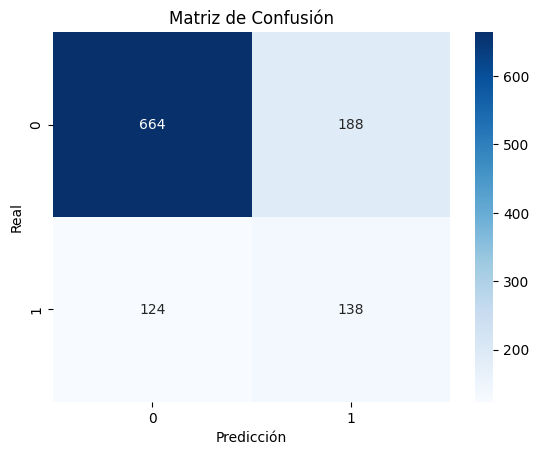

In [202]:
#Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [203]:
#Reporte completo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       852
           1       0.42      0.53      0.47       262

    accuracy                           0.72      1114
   macro avg       0.63      0.65      0.64      1114
weighted avg       0.74      0.72      0.73      1114



VALIDACIÓN FINAL DEL ENTRENAMIENTO:

In [204]:
y_val_pred = model.predict(X_val)
print("validación:", f1_score(y_val, y_val_pred))

validación: 0.5315068493150685
